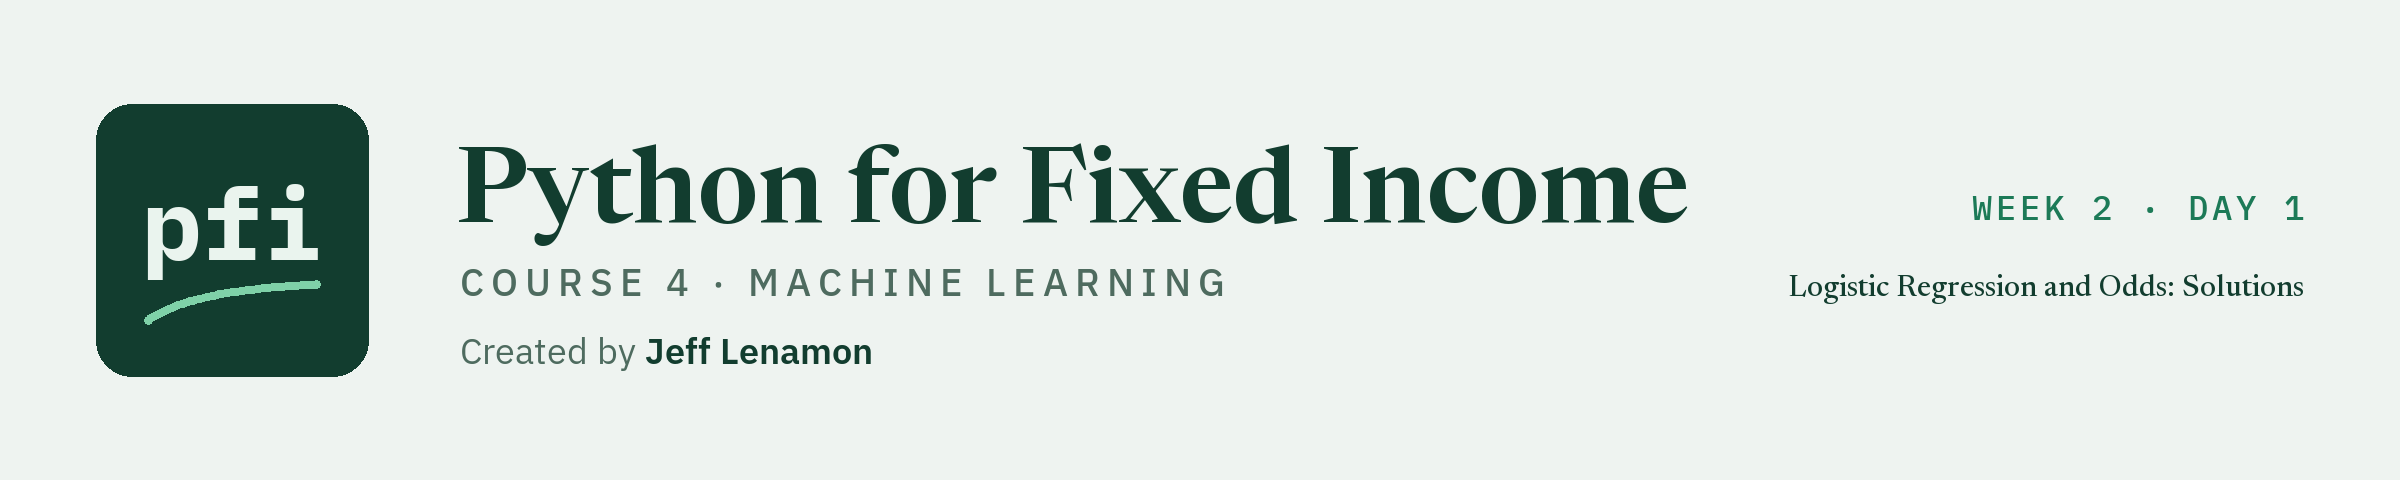

# Logistic Regression and Odds: Solutions

Week 2, Day 1. Worked answers to the exercises. Try each one yourself first.

**Data:** `credit_card_default.csv`, 30,000 card accounts in Taiwan in 2005: **real**, UCI Machine Learning Repository dataset 350, CC BY 4.0. Citation: Yeh, I. (2009). Default of Credit Card Clients [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course4_machine_learning/week2/day1/06_logistic_regression_and_odds_solutions.ipynb)

This notebook stands on its own. Its setup writes `mlkit.py` and `test_mlkit.py` as they stand at the end of today, so the exercises can be run without the lesson. The four person columns are never model features here either.

Q. Set up today's work folder.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, or scikit-learn is imported: if you ran another cell first,
# restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# four packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("pytest", "pytest")]:
    try:
        importlib.import_module(module_name)
    except ImportError:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.") from None

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course4_machine_learning/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "statsmodels": "0.15.0", "scipy": "1.18.1", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "benchmark.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course4_06_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["benchmark.csv", "ratings.csv", "course4_excel_reference.csv", "credit_card_default.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, statsmodels 0.15.0, scipy 1.18.1, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course4_06_vzr1mq3o, in your temp folder
Data files from the data folder of the course repo: benchmark.csv, ratings.csv, course4_excel_reference.csv, credit_card_default.csv
SEED = 42


Q. Write `mlkit.py` and `test_mlkit.py` as they stand at the end of today.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability

Writing mlkit.py


In [3]:
%%writefile test_mlkit.py
"""Tests for mlkit.py.

Expected values come from Excel (course4_excel_reference.csv in this folder), from scikit-learn or statsmodels on
the same inputs, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

import mlkit

HERE = Path(__file__).resolve().parent
SEED = 42


def read_bench() -> pd.DataFrame:
    """The 821 synthetic benchmark bonds joined to their rating score, with log_oas (natural log of bp)."""
    bench = pd.read_csv(HERE / "benchmark.csv")
    ratings = pd.read_csv(HERE / "ratings.csv")
    bench = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    bench["log_oas"] = np.log(bench["oas"])
    return bench


def excel(case_id: str) -> float:
    """One value computed by Excel, looked up by its case_id (model:quantity)."""
    reference = pd.read_csv(HERE / "course4_excel_reference.csv", float_precision="round_trip")
    return float(reference.set_index("case_id").loc[case_id, "excel_value"])


def test_assert_disjoint_passes():
    mlkit.assert_disjoint([0, 1, 2], [3, 4])


def test_assert_disjoint_raises_with_count():
    with pytest.raises(AssertionError, match="2 row labels"):
        mlkit.assert_disjoint([0, 1, 2, 3], [2, 3, 4])


def test_regression_metrics_hand_values():
    # errors 10, -10, 30 bp around a mean of 200 bp
    metrics = mlkit.regression_metrics([100.0, 200.0, 300.0], [110.0, 190.0, 330.0])
    assert metrics["mae"] == pytest.approx(50 / 3, abs=1e-12)
    assert metrics["rmse"] == pytest.approx(np.sqrt(1100 / 3), abs=1e-12)
    # SS_res 1,100 over SS_tot 20,000
    assert metrics["r2"] == pytest.approx(1 - 1100 / 20000, abs=1e-12)


def test_regression_metrics_match_sklearn():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(r2_score(bench["oas"], fitted), abs=1e-12)
    assert metrics["mae"] == pytest.approx(mean_absolute_error(bench["oas"], fitted), abs=1e-12)
    assert metrics["rmse"] == pytest.approx(root_mean_squared_error(bench["oas"], fitted), abs=1e-12)
    with pytest.raises(ValueError):
        mlkit.regression_metrics([1.0, 2.0], [1.0])


def test_slope_matches_excel_reference():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    # Excel: =SLOPE(oas, score), =INTERCEPT(oas, score), =RSQ(oas, score) over the 821 bonds
    assert slope == pytest.approx(excel("d01_oas_on_score:slope"), abs=1e-9)
    assert intercept == pytest.approx(excel("d01_oas_on_score:intercept"), abs=1e-9)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(excel("d01_oas_on_score:rsq"), abs=1e-9)
    # Excel: =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)), in bp
    assert metrics["mae"] == pytest.approx(excel("d01_oas_on_score:mae_bp"), abs=1e-9)
    assert metrics["rmse"] == pytest.approx(excel("d01_oas_on_score:rmse_bp"), abs=1e-9)


import statsmodels.api as sm


def rating_levels() -> list[str]:
    """Every rating level, AAA to CCC, in the order of ratings.csv."""
    return pd.read_csv(HERE / "ratings.csv")["rating"].tolist()


def sector_dummies(sectors: pd.Series, reference: str = "Consumer") -> pd.DataFrame:
    """One float column per sector except the reference, named sector_<name>, in alphabetical order."""
    return pd.DataFrame({f"sector_{s}": (sectors == s).astype(float) for s in sorted(sectors.unique())
                         if s != reference}, index=sectors.index)


def test_adjusted_r2_hand_value():
    # 1 - (1 - 0.8) x 99 / 96
    assert mlkit.adjusted_r2(0.8, 100, 3) == pytest.approx(1 - 0.2 * 99 / 96, abs=1e-12)


def test_adjusted_r2_rejects_too_few_rows():
    with pytest.raises(ValueError):
        mlkit.adjusted_r2(0.8, 4, 3)


def test_rating_dummies_reference_absent():
    ratings = pd.Series(["AAA", "A", "BBB", "A"])
    dummies = mlkit.rating_dummies(ratings, ["AAA", "A", "BBB"], reference="A")
    assert list(dummies.columns) == ["rating_AAA", "rating_BBB"]
    # an A-rated bond has every indicator at 0.0: the intercept stands for it
    assert dummies.loc[1].tolist() == [0.0, 0.0]
    assert dummies.dtypes.eq(float).all()


def test_rating_dummies_unknown_level_raises():
    with pytest.raises(ValueError, match="BB"):
        mlkit.rating_dummies(pd.Series(["AAA", "BB"]), ["AAA", "A"], reference="A")
    with pytest.raises(ValueError):
        mlkit.rating_dummies(pd.Series(["AAA"]), ["AAA", "A"], reference="CCC")


def test_linest_multi_matches_excel_reference():
    bench = read_bench()
    X = pd.concat([mlkit.rating_dummies(bench["rating"], rating_levels(), reference="A"),
                   bench[["duration"]], sector_dummies(bench["sector"])], axis=1)
    fit = sm.OLS(bench["oas"], sm.add_constant(X)).fit()
    model = "d02_oas_on_rating_duration_sector"
    # Excel's LINEST reverses the columns; the reference file names each value in statsmodels' order
    for name in ["const"] + list(X.columns):
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
    assert fit.rsquared == pytest.approx(excel(f"{model}:r2"), abs=1e-9)
    assert fit.df_resid == excel(f"{model}:df_resid")
    assert fit.fvalue == pytest.approx(excel(f"{model}:f"), rel=1e-9)
    adjusted = mlkit.adjusted_r2(fit.rsquared, len(X), X.shape[1])
    assert adjusted == pytest.approx(excel(f"{model}:adj_r2"), abs=1e-9)
    assert adjusted == pytest.approx(fit.rsquared_adj, abs=1e-12)


from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor


def m3_features(bench: pd.DataFrame) -> pd.DataFrame:
    """Rating score, duration, and the nine sector dummies (reference Consumer): the day 3 inference model."""
    return pd.concat([bench[["score", "duration"]], sector_dummies(bench["sector"])], axis=1)


def test_vif_matches_statsmodels():
    X = m3_features(read_bench())
    vifs = mlkit.vif_table(X)
    with_constant = sm.add_constant(X).to_numpy()
    for j, name in enumerate(X.columns, start=1):
        assert vifs[name] == pytest.approx(variance_inflation_factor(with_constant, j), abs=1e-9), name
    # sorted from the highest VIF down
    assert vifs.is_monotonic_decreasing


def test_vif_matches_excel_reference():
    vifs = mlkit.vif_table(m3_features(read_bench()))
    for name, value in vifs.items():
        # Excel: =1/(1-INDEX(LINEST(xj, the other columns, TRUE, TRUE), 3, 1))
        assert value == pytest.approx(excel(f"d03_vif:vif_{name}"), abs=1e-9), name


def test_vif_perfect_collinearity_is_huge():
    bench = read_bench()
    # spread_duration equals duration on every bond of the file
    vifs = mlkit.vif_table(bench[["score", "duration", "spread_duration"]])
    assert vifs["duration"] > 1e10
    assert vifs["spread_duration"] > 1e10
    assert vifs["score"] < 5


def test_ols_matches_sklearn():
    bench = read_bench()
    X = m3_features(bench)
    fit = sm.OLS(bench["log_oas"], sm.add_constant(X)).fit()
    linear = LinearRegression().fit(X, bench["log_oas"])
    assert linear.intercept_ == pytest.approx(fit.params["const"], abs=1e-9)
    for name, value in zip(X.columns, linear.coef_):
        assert value == pytest.approx(fit.params[name], abs=1e-9), name
    # and both against Excel's LINEST, with its standard errors and T.DIST.2T p-values
    model = "d03_log_oas_on_score_duration_sector"
    for name in fit.params.index:
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
        assert fit.pvalues[name] == pytest.approx(excel(f"{model}:p_{name}"), abs=1e-9), name


from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan


def test_residual_tests_match_statsmodels_and_scipy():
    bench = read_bench()
    X = pd.concat([mlkit.rating_dummies(bench["rating"], rating_levels(), reference="A"),
                   bench[["duration"]], sector_dummies(bench["sector"])], axis=1)
    fit = sm.OLS(bench["log_oas"], sm.add_constant(X)).fit()
    result = mlkit.residual_tests(fit.resid, X)
    assert result["breusch_pagan"] == pytest.approx(het_breuschpagan(fit.resid, sm.add_constant(X))[1], abs=1e-12)
    assert result["jarque_bera"] == pytest.approx(stats.jarque_bera(fit.resid).pvalue, abs=1e-12)
    assert result["shapiro_wilk"] == pytest.approx(stats.shapiro(fit.resid).pvalue, abs=1e-12)
    # Excel: LM = n x INDEX(LINEST(squared residuals, X, TRUE, TRUE), 3, 1), then CHISQ.DIST.RT(LM, k)
    model = "d04_breusch_pagan_log_oas_model"
    assert het_breuschpagan(fit.resid, sm.add_constant(X))[0] == pytest.approx(excel(f"{model}:lm"), rel=1e-9)
    assert result["breusch_pagan"] == pytest.approx(excel(f"{model}:lm_pvalue"), abs=1e-9)


def test_residual_tests_normal_sample():
    rng = np.random.default_rng(SEED)
    exog = pd.DataFrame({"x": rng.uniform(0, 10, 500)})
    residuals = pd.Series(rng.normal(0, 1, 500))
    # residuals drawn normal with constant variance: no check rejects at 0.05
    result = mlkit.residual_tests(residuals, exog)
    assert min(result.values()) > 0.05


def test_residual_tests_fan_rejected():
    rng = np.random.default_rng(SEED)
    x = np.arange(1.0, 201.0)
    # the spread of the residuals grows with x: a fan
    residuals = pd.Series(x * rng.normal(0, 1, 200))
    result = mlkit.residual_tests(residuals, pd.DataFrame({"x": x}))
    assert result["breusch_pagan"] < 0.001
    with pytest.raises(ValueError):
        mlkit.residual_tests(residuals, pd.DataFrame({"x": x[:10]}))


from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor


def spread_pipeline(model) -> Pipeline:
    """Rating and sector one-hot (references A and Consumer), duration and coupon scaled, then `model`."""
    encode = ColumnTransformer([
        ("categories", OneHotEncoder(drop=["A", "Consumer"], handle_unknown="ignore"), ["rating", "sector"]),
        ("numbers", StandardScaler(), ["duration", "coupon"]),
    ])
    return Pipeline([("encode", encode), ("model", model)])


def test_named_coefficients_align_with_names():
    bench = read_bench()
    X, y = bench[["rating", "sector", "duration", "coupon"]], bench["log_oas"]
    pipeline = spread_pipeline(LinearRegression()).fit(X, y)
    coefficients = mlkit.named_coefficients(pipeline)
    assert list(coefficients.index) == list(pipeline[:-1].get_feature_names_out())
    assert np.array_equal(coefficients.to_numpy(), pipeline[-1].coef_)
    # the reference levels have no coefficient
    assert "categories__rating_A" not in coefficients.index
    assert "categories__sector_Consumer" not in coefficients.index
    assert "categories__rating_AAA" in coefficients.index


def test_named_coefficients_rejects_tree():
    bench = read_bench()
    pipeline = spread_pipeline(DecisionTreeRegressor(max_depth=2, random_state=SEED))
    pipeline.fit(bench[["rating", "sector", "duration", "coupon"]], bench["log_oas"])
    with pytest.raises(ValueError, match="coef_"):
        mlkit.named_coefficients(pipeline)


def test_pipeline_scaler_fitted_on_train_only():
    bench = read_bench()
    X, y = bench[["duration", "coupon", "score"]], bench["log_oas"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)
    mlkit.assert_disjoint(X_train.index, X_test.index)
    pipeline = Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=10))]).fit(X_train, y_train)
    # the scaler learned the training rows' means and population standard deviations, not all rows'
    assert np.allclose(pipeline["scale"].mean_, X_train.mean().to_numpy(), rtol=0, atol=1e-12)
    assert np.allclose(pipeline["scale"].scale_, X_train.std(ddof=0).to_numpy(), rtol=0, atol=1e-12)
    assert not np.allclose(pipeline["scale"].mean_, X.mean().to_numpy(), rtol=0, atol=1e-6)


from sklearn.linear_model import LogisticRegression

CARD_TARGET = "default payment next month"


def read_card() -> pd.DataFrame:
    """The 30,000 UCI card accounts, with LIMIT_BAL also in units of 10,000 NT dollars."""
    card = pd.read_csv(HERE / "credit_card_default.csv")
    card["LIMIT_BAL_10k"] = card["LIMIT_BAL"] / 10_000
    return card


def test_logistic_probability_hand_values():
    assert mlkit.logistic_probability(0.0) == pytest.approx(0.5, abs=1e-12)
    # log-odds of ln 3 are odds of 3 to 1, a probability of 0.75
    assert mlkit.logistic_probability(np.log(3)) == pytest.approx(0.75, abs=1e-12)
    probabilities = mlkit.logistic_probability(np.array([-np.log(3), 0.0]))
    assert probabilities == pytest.approx([0.25, 0.5], abs=1e-12)


def test_odds_ratios_exp():
    coefficients = pd.Series({"const": -1.4, "PAY_0": np.log(2.0), "LIMIT_BAL_10k": 0.0})
    ratios = mlkit.odds_ratios(coefficients)
    assert list(ratios.index) == ["PAY_0", "LIMIT_BAL_10k"]
    assert ratios["PAY_0"] == pytest.approx(2.0, abs=1e-12)
    assert ratios["LIMIT_BAL_10k"] == pytest.approx(1.0, abs=1e-12)
    with pytest.raises(ValueError):
        mlkit.odds_ratios(pd.Series({"const": 1.0}))


@pytest.mark.parametrize("model, features", [
    ("d06_logit_default_on_pay0", ["PAY_0"]),
    ("d06_logit_default_on_pay0_limit10k", ["PAY_0", "LIMIT_BAL_10k"]),
])
def test_logit_matches_excel_solver_reference(model, features):
    card = read_card()
    logit = sm.Logit(card[CARD_TARGET], sm.add_constant(card[features]))
    fit = logit.fit(disp=0)
    # Excel Solver, non-negative box off, maximising the summed log-likelihood column
    solver = pd.Series({name: excel(f"{model}:coef_{name}") for name in ["const"] + features})
    for name in solver.index:
        assert fit.params[name] == pytest.approx(solver[name], abs=1e-4), name
    # the log-likelihood Excel summed, at Excel's own coefficients
    assert logit.loglike(solver[fit.params.index].to_numpy()) == pytest.approx(excel(f"{model}:loglik"), abs=1e-6)
    # Excel: =EXP(coef) as an odds ratio
    for name, ratio in mlkit.odds_ratios(solver).items():
        assert ratio == pytest.approx(excel(f"{model}:odds_ratio_{name}"), abs=1e-12)


@pytest.mark.parametrize("features", [["PAY_0"], ["PAY_0", "LIMIT_BAL_10k"]])
def test_sklearn_cinf_matches_statsmodels(features):
    card = read_card()
    fit = sm.Logit(card[CARD_TARGET], sm.add_constant(card[features])).fit(disp=0)
    # C=np.inf switches the default L2 penalty off; penalty= is never used (deprecated in scikit-learn 1.8).
    # tol=1e-8: with the default tol=1e-4 the solver stops 2.2e-4 away on PAY_0 alone
    model = LogisticRegression(C=np.inf, tol=1e-8, max_iter=1000).fit(card[features], card[CARD_TARGET])
    assert model.intercept_[0] == pytest.approx(fit.params["const"], abs=1e-4)
    for name, value in zip(features, model.coef_[0]):
        assert value == pytest.approx(fit.params[name], abs=1e-4), name

Writing test_mlkit.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)

# the functions defined in the module itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(mlkit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "mlkit" and not name.startswith("_")]
print(f"mlkit functions: {functions}")

mlkit functions: ['assert_disjoint', 'regression_metrics', 'adjusted_r2', 'rating_dummies', 'vif_table', 'residual_tests', 'named_coefficients', 'odds_ratios', 'logistic_probability']


## Exercises

The exercises use the same card file, the same split, and the training rows only: 30,000 real accounts in Taiwan in 2005 (UCI, CC BY 4.0), with the four person columns never used as features. Every answer describes this file; none is a statement about a person or a lending rule. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the card file, makes the week's split, fits section 6.4's model on the training rows, and defines `check`, a small function that marks your answers.

In [5]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

# the card file, the 19 features, and the week's split, as at the top of the notebook
card = pd.read_csv("credit_card_default.csv")
TARGET = "default payment next month"
PERSON_COLUMNS = ["SEX", "EDUCATION", "MARRIAGE", "AGE"]
FEATURES = [column for column in card.columns if column not in ["ID", TARGET] + PERSON_COLUMNS]
X_rest, X_test, y_rest, y_test = train_test_split(card[FEATURES], card[TARGET], test_size=0.2, stratify=card[TARGET],
                                                  random_state=SEED)
X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest,
                                                      random_state=SEED)

# section 6.4's model: PAY_0 and the limit per 10,000 NT dollars, on the training rows
X_train_2 = X_train[["PAY_0"]].assign(LIMIT_BAL_10k=X_train["LIMIT_BAL"] / 10_000)
logit_2 = sm.Logit(y_train, sm.add_constant(X_train_2)).fit(disp=0)


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. `PAY_2` is the repayment status in August 2005, a month before `PAY_0`. Fit a logistic regression of default on `PAY_2` alone on the training rows with statsmodels. Store its coefficient in log odds in **ex1_coefficient** and its odds ratio per step up the codes in **ex1_odds_ratio**.

In [6]:
# the same model as section 6.4's first one, with August's status in place of September's
logit_pay2 = sm.Logit(y_train, sm.add_constant(X_train[["PAY_2"]])).fit(disp=0)

ex1_coefficient = logit_pay2.params["PAY_2"]
ex1_odds_ratio = mlkit.odds_ratios(logit_pay2.params)["PAY_2"]
print(f"PAY_2: coefficient {ex1_coefficient:.4f} in log odds, odds ratio {ex1_odds_ratio:.4f} per step up the codes")

PAY_2: coefficient 0.5199 in log odds, odds ratio 1.6819 per step up the codes


* 1.6819 per step, against 2.1602 for `PAY_0` alone. The older month goes with a smaller odds ratio in this file. Like every odds ratio here it describes an association in these accounts, with the codes used as evenly spaced numbers.

In [7]:
check("Exercise 1 the coefficient", ex1_coefficient, 0.519932297306084)
check("Exercise 1 the odds ratio", ex1_odds_ratio, 1.6819137757505906)

Exercise 1 the coefficient: correct
Exercise 1 the odds ratio: correct


### Exercise 2

Q. Section 6.4 read the limit's odds ratio per 10,000 NT dollars. Using `logit_2`, what is it per **50,000** NT dollars, holding `PAY_0` fixed? Store it in **ex2_odds_ratio_50k**.

In [8]:
# 50,000 NT dollars is 5 units of 10,000, so the log odds move by 5 times the coefficient
ex2_odds_ratio_50k = np.exp(5 * logit_2.params["LIMIT_BAL_10k"])

# the same as the odds ratio per 10,000 NT dollars multiplied five times
per_10k = mlkit.odds_ratios(logit_2.params)["LIMIT_BAL_10k"]
print(f"per 50,000 NT dollars: {ex2_odds_ratio_50k:.4f}; per 10,000 to the fifth power: {per_10k ** 5:.4f}")

per 50,000 NT dollars: 0.9034; per 10,000 to the fifth power: 0.9034


* 0.9034: about 9.7 percent lower odds for 50,000 NT dollars more of limit, at the same `PAY_0` code, in this file. Changing the unit multiplies the coefficient and raises the odds ratio to a power; the model is the same. Never `5 * odds ratio`: odds ratios multiply, they do not add.

In [9]:
check("Exercise 2 the odds ratio per 50,000 NT dollars", ex2_odds_ratio_50k, 0.9033575637518404)

Exercise 2 the odds ratio per 50,000 NT dollars: correct


### Exercise 3

Q. Add a function to your module. `odds(p)` returns the odds p / (1 - p) of an event with probability p, and raises `ValueError` when p is below 0, or 1 or more. Write the docstring first, with the range of p. Then add `test_odds_hand_values`: 0.5 gives 1, 0.75 gives 3, 0.2 gives 0.25, `logistic_probability(log(odds(0.3)))` gives back 0.3, and 1.0 raises. Run pytest, reload the module, and store `mlkit.odds(y_train.mean())`, the odds of default on the training rows, in **ex3_training_odds**.

Write the function in the cell that starts with `%%writefile -a mlkit.py` and the test in the one that starts with `%%writefile -a test_mlkit.py`, and run each of those cells once.

In [10]:
%%writefile -a mlkit.py


def odds(p: float) -> float:
    """The odds of an event with probability p: p / (1 - p).

    Input: p, a probability from 0 up to, but not including, 1. Output: the odds, from 0 to infinity; 0.75
    gives 3.0 (three to one), 0.2 gives 0.25. Excel: =p/(1-p)
    Raises ValueError if p is below 0, or 1 or more (the odds of a certain event are infinite).
    """
    if not 0 <= p < 1:
        raise ValueError(f"p must be from 0 up to, but not including, 1; got {p}")
    return p / (1 - p)

Appending to mlkit.py


In [11]:
%%writefile -a test_mlkit.py


def test_odds_hand_values():
    assert mlkit.odds(0.5) == pytest.approx(1.0, abs=1e-12)
    assert mlkit.odds(0.75) == pytest.approx(3.0, abs=1e-12)
    assert mlkit.odds(0.2) == pytest.approx(0.25, abs=1e-12)
    # the curve undoes the odds: log odds back to the probability
    assert mlkit.logistic_probability(np.log(mlkit.odds(0.3))) == pytest.approx(0.3, abs=1e-12)
    with pytest.raises(ValueError):
        mlkit.odds(1.0)

Appending to test_mlkit.py


In [12]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_mlkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

...........................                                              [100%]
27 passed in 2.32s



In [13]:
# the file changed, so reload before calling the new function
importlib.reload(mlkit)
ex3_training_odds = mlkit.odds(y_train.mean())
print(f"training default rate {y_train.mean():.4f}; odds {ex3_training_odds:.4f}")

training default rate 0.2212; odds 0.2841


* `27 passed`: today's 26 and the new one.
* Odds of 0.2841: about one default for every 3.5 accounts that did not, on the training rows. The `ValueError` matters: at p = 1 the division would give infinity or an error far from the cause, and the message says what went wrong.

In [14]:
check("Exercise 3 the odds of default on the training rows", ex3_training_odds, 0.2840633471251248)

Exercise 3 the odds of default on the training rows: correct


### Exercise 4: AI check

You ask an AI assistant for a function that fits a logistic regression and returns its odds ratios, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Odds ratios of a logistic regression of default on the given features, fitted on the training rows.

    Fit: statsmodels Logit of y_train on X_train[features] with a constant, unpenalised.
    Returns: a Series with one odds ratio per feature: exp of its coefficient, the factor by which the odds
    of default multiply for one more unit of that feature, the other features fixed. No intercept.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns one number per feature, and contains one bug.

* The bug: `fit.params.drop("const")` returns the **coefficients**, in log odds, and labels them odds ratios. It never takes `exp`. Read as odds ratios, `PAY_0`'s 0.7213 says a higher code goes with *lower* odds (an odds ratio below 1), the opposite of section 6.4's 2.0571; and the limit's -0.0203 is below zero, which no odds ratio can be.
* The fix, in the cell below: return `mlkit.odds_ratios(fit.params)`, which takes `exp` and leaves out the intercept.

In [15]:
def odds_ratio_table(X_train, y_train, features):
    """Odds ratios of a logistic regression of default on the given features, fitted on the training rows.

    Fit: statsmodels Logit of y_train on X_train[features] with a constant, unpenalised.
    Returns: a Series with one odds ratio per feature: exp of its coefficient, the factor by which the odds
    of default multiply for one more unit of that feature, the other features fixed. No intercept.
    """
    fit = sm.Logit(y_train, sm.add_constant(X_train[features])).fit(disp=0)
    # the fix: an odds ratio is exp of the coefficient; odds_ratios takes exp and leaves out the intercept
    return mlkit.odds_ratios(fit.params)

In [16]:
# the same test, now against mlkit.odds_ratios itself
ratios = odds_ratio_table(X_train_2, y_train, ["PAY_0", "LIMIT_BAL_10k"])
fit = sm.Logit(y_train, sm.add_constant(X_train_2)).fit(disp=0)
assert (ratios > 0).all(), "an odds ratio at or below 0"
pd.testing.assert_series_equal(ratios, mlkit.odds_ratios(fit.params), check_exact=False, rtol=0, atol=1e-12)
print("odds_ratio_table returns odds ratios")

odds_ratio_table returns odds ratios


In [17]:
ex4_pay0_odds_ratio = odds_ratio_table(X_train_2, y_train, ["PAY_0", "LIMIT_BAL_10k"])["PAY_0"]
print(f"fixed: odds ratio of PAY_0 {ex4_pay0_odds_ratio:.4f} per step, as in section 6.4")

fixed: odds ratio of PAY_0 2.0571 per step, as in section 6.4


* The fixed function gives section 6.4's odds ratios exactly. Two quick checks catch this bug on sight: an odds ratio is never below 0, and a coefficient and its odds ratio agree on direction only through `exp` (a positive coefficient is an odds ratio above 1).

In [18]:
check("Exercise 4 the fixed function's odds ratio for PAY_0", ex4_pay0_odds_ratio, 2.0570903919202737)

Exercise 4 the fixed function's odds ratio for PAY_0: correct


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```